# ProQuest TDM Archive — Descriptive Overview

This notebook loads all `.csv.gz` exports from ProQuest TDM Studio (expected under `/data/mourad/narratives/proquest/raw_from_TDM/`) and surfaces summary statistics about article coverage, source diversity, and document lengths. Update `DATA_DIR` below if the files live somewhere else.

## Notebook goals

- Inspect available exports and confirm schema
- Combine the files into a single DataFrame
- Produce yearly article and source counts
- Highlight top publications and datelines
- Explore article length distributions

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.options.display.max_rows = 50
pd.options.display.max_columns = 20

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 5)


In [3]:
DATA_DIR = Path("/data/mourad/narratives/proquest/raw_from_TDM")

if not DATA_DIR.exists():
    print(f"Warning: {DATA_DIR} was not found. Falling back to /data/mourad/narratives/proquest")
    DATA_DIR = Path("/data/mourad/narratives/proquest")

csv_paths = sorted(DATA_DIR.glob("*.csv.gz"))

if not csv_paths:
    raise FileNotFoundError(f"No .csv.gz exports found in {DATA_DIR}")

file_info = pd.DataFrame(
    {
        "filename": [path.name for path in csv_paths],
        "size_mb": [round(path.stat().st_size / 1024**2, 2) for path in csv_paths],
    }
).sort_values("filename")

display(file_info)
print(f"Total files discovered: {len(csv_paths)}")


,filename,size_mb
0,local-data-2.csv.gz,95.94
1,local-data-3-national.csv.gz,106.58
2,local-data.csv.gz,222.60
3,processed-data-1923-1960.csv.gz,76.92
4,processed-data-2010-2025.csv.gz,124.08
5,processed-data-2010-2025_updated.csv.gz,156.47


Total files discovered: 6


In [4]:
def load_proquest_csvs(paths, usecols=None):
    frames = []
    for path in paths:
        print(f"Loading {path.name} ...")
        df = pd.read_csv(
            path,
            sep="	",
            compression="infer",
            usecols=usecols,
            dtype="string",
            on_bad_lines="skip",
        )
        df["source_file"] = path.name
        frames.append(df)

    if not frames:
        raise ValueError("No frames were loaded; check the glob pattern or file permissions.")

    return pd.concat(frames, ignore_index=True)


In [5]:
columns_to_keep = ["file_id", "year_month", "title", "loc", "text"]
articles = load_proquest_csvs(csv_paths, usecols=columns_to_keep)

articles = articles.rename(columns={"file_id": "article_id", "title": "source_title"})

articles["article_id"] = articles["article_id"].astype("string")
articles["source_title"] = articles["source_title"].str.strip()
articles["loc"] = articles["loc"].str.strip()

articles["year_month"] = pd.to_datetime(articles["year_month"], format="%Y-%m", errors="coerce")
articles["year"] = articles["year_month"].dt.year
articles["month"] = articles["year_month"].dt.month

articles["word_count"] = (
    articles["text"]
    .fillna("")
    .str.split()
    .map(len)
)

print(f"Combined rows: {len(articles):,}")
display(articles.head())


Loading local-data-2.csv.gz ...
Loading local-data-3-national.csv.gz ...
Loading local-data.csv.gz ...
Loading processed-data-1923-1960.csv.gz ...
Loading processed-data-2010-2025.csv.gz ...
Loading processed-data-2010-2025_updated.csv.gz ...
Combined rows: 6,881,680


,article_id,year_month,source_title,loc,text,source_file,year,month,word_count
0,381143755,2006-07-01,Salina Journal The,"Salina, Kan.","The assessment, however, assumes prices will s...",local-data-2.csv.gz,2006,7,15
1,368798418,2007-09-01,Telegraph - Herald,"Dubuque, Iowa","The market's losses were small, thanks to posi...",local-data-2.csv.gz,2007,9,18
2,368798418,2007-09-01,Telegraph - Herald,"Dubuque, Iowa",Though strong economic data might lower the ch...,local-data-2.csv.gz,2007,9,27
3,268012663,1991-02-01,Gazette The,"Colorado Springs, Colo.",Medical costs and prescriptions have risen at...,local-data-2.csv.gz,1991,2,21
4,240238212,1997-05-01,Indianapolis Star,"Indianapolis, Ind.","They do need some increase, but not more tha...",local-data-2.csv.gz,1997,5,10


In [6]:
date_min = articles["year_month"].min()
date_max = articles["year_month"].max()

summary_rows = [
    ("Rows", f"{len(articles):,}"),
    ("Unique articles", f"{articles['article_id'].nunique(dropna=True):,}"),
    ("Unique sources", f"{articles['source_title'].nunique(dropna=True):,}"),
    ("Unique locations", f"{articles['loc'].nunique(dropna=True):,}"),
    (
        "Date range",
        f"{date_min.date()} — {date_max.date()}" if pd.notna(date_min) and pd.notna(date_max) else "Not available",
    ),
    ("Missing year_month values", f"{articles['year_month'].isna().sum():,}"),
]

summary_df = pd.DataFrame(summary_rows, columns=["metric", "value"])
display(summary_df)


,metric,value
0,Rows,"6,881,680"
1,Unique articles,"2,717,127"
2,Unique sources,"1,072"
3,Unique locations,626
4,Date range,1923-01-01 — 2025-07-01
5,Missing year_month values,0


In [7]:
yearly = (
    articles.dropna(subset=["year"])
    .groupby("year")
    .agg(
        total_records=("article_id", "size"),
        unique_articles=("article_id", "nunique"),
        unique_sources=("source_title", "nunique"),
        mean_word_count=("word_count", "mean"),
        median_word_count=("word_count", "median"),
    )
    .reset_index()
    .sort_values("year")
)

display(yearly)


,year,total_records,unique_articles,unique_sources,mean_word_count,median_word_count
0,1923,4167,2837,22,72.572594,33.0
1,1924,2976,2120,22,77.370296,33.0
2,1925,3613,2520,21,103.211459,34.0
3,1926,2949,2218,25,92.853849,33.0
4,1927,1754,1382,20,96.598632,34.0
...,...,...,...,...,...,...
98,2021,208333,41705,360,34.566180,26.0
99,2022,652973,137130,377,33.267426,26.0
100,2023,414295,103808,435,40.690945,27.0
101,2024,355405,103651,429,38.511040,26.0


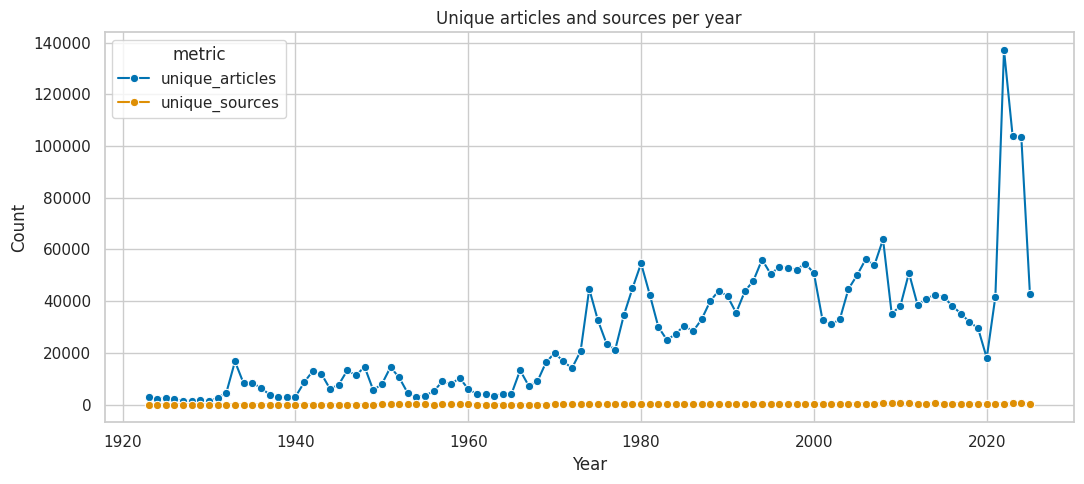

In [8]:
yearly_melted = yearly.melt(
    id_vars="year",
    value_vars=["unique_articles", "unique_sources"],
    var_name="metric",
    value_name="count",
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=yearly_melted, x="year", y="count", hue="metric", marker="o", ax=ax)
ax.set_title("Unique articles and sources per year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


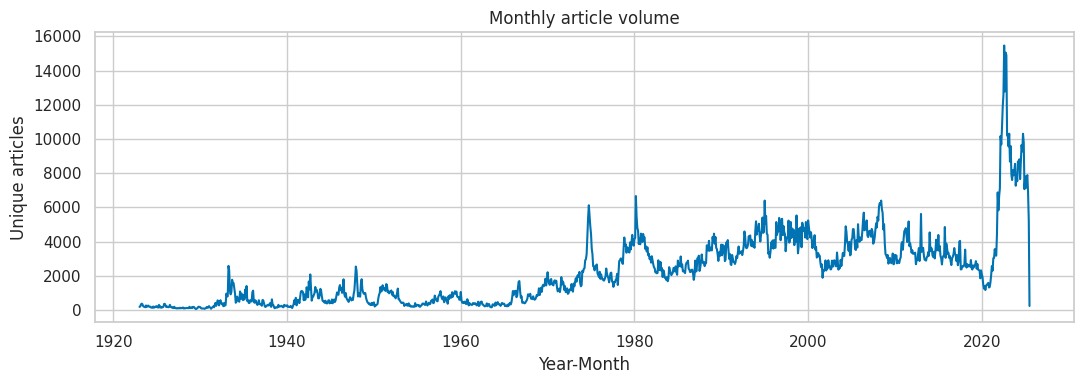

In [9]:
monthly = (
    articles.dropna(subset=["year_month"])
    .groupby("year_month")["article_id"]
    .nunique()
    .reset_index(name="unique_articles")
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=monthly, x="year_month", y="unique_articles", ax=ax)
ax.set_title("Monthly article volume")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Unique articles")
plt.tight_layout()
plt.show()


In [10]:
top_sources = (
    articles.groupby("source_title")["article_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(25)
    .reset_index()
    .rename(columns={"article_id": "unique_articles"})
)

display(top_sources)


,source_title,unique_articles
0,New York Times (1923-),134189
1,Los Angeles Times (1923-1995),100288
2,Targeted News Service,94054
3,Wall Street Journal (1923-),85634
4,Wall Street Journal,76833
5,New York Times,69249
6,PR Newswire,68660
7,St. Louis Post-Dispatch (1923-),65869
8,Chicago Tribune (1963-1996),61614
9,Wall Street Journal (Online),60391


In [11]:
top_sources_by_year = (
    articles.dropna(subset=["year"])
    .groupby(["year", "source_title"])["article_id"]
    .nunique()
    .reset_index(name="unique_articles")
)

if top_sources_by_year.empty:
    print("No valid year/source combinations found.")
else:
    max_year = top_sources_by_year["year"].max()
    recent_slice = top_sources_by_year[top_sources_by_year["year"] >= max_year - 9]
    top_sources_recent = (
        recent_slice
        .sort_values(["year", "unique_articles"], ascending=[True, False])
        .groupby("year")
        .head(10)
    )
    display(top_sources_recent)


,year,source_title,unique_articles
11307,2016,Wall Street Journal (Online),5292
11268,2016,TCA Regional News,2946
11274,2016,Targeted News Service,2386
11300,2016,University Wire,1881
10987,2016,Business Wire,1851
...,...,...,...
14605,2025,New York Times (Online),1396
14398,2025,Barron's (Online),1290
14526,2025,Insider,1273
14604,2025,New York Times,988


In [12]:
top_locations = (
    articles["loc"]
    .dropna()
    .value_counts()
    .head(25)
    .rename_axis("loc")
    .reset_index(name="article_mentions")
)

display(top_locations)


,loc,article_mentions
0,"New York, N.Y.",1564334
1,"Washington, D.C.",787469
2,New York,649646
3,"Chicago, Ill.",352674
4,"Los Angeles, Calif.",322789
5,Washington,205904
6,Chicago,171927
7,"Boston, Mass.",165072
8,Minneapolis,154999
9,St Louis,120714


,word_count_stats
count,6.881680e+06
mean,4.659200e+01
std,1.255563e+02
min,0.000000e+00
10%,1.100000e+01
25%,1.800000e+01
50%,2.600000e+01
75%,3.600000e+01
90%,5.200000e+01
max,2.160300e+04


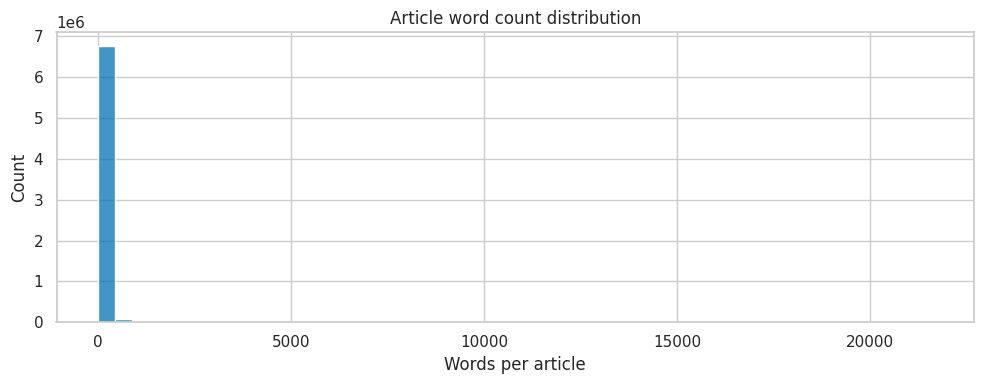

In [13]:
word_stats = articles["word_count"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame(name="word_count_stats")
display(word_stats)

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(articles["word_count"].dropna(), bins=50, ax=ax)
ax.set_title("Article word count distribution")
ax.set_xlabel("Words per article")
plt.tight_layout()
plt.show()


In [14]:
# Optional: export summary tables for downstream analysis
OUTPUT_DIR = Path("src/preprocess/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

yearly.to_csv(OUTPUT_DIR / "proquest_articles_by_year.csv", index=False)
top_sources.to_csv(OUTPUT_DIR / "proquest_top_sources.csv", index=False)
monthly.to_csv(OUTPUT_DIR / "proquest_articles_by_month.csv", index=False)

print(f"Exported summary tables to {OUTPUT_DIR.resolve()}")


Exported summary tables to /home/mourad/causal-micro-narratives/src/preprocess/src/preprocess/output


In [15]:
# Identify significant changes in unique articles and sources (monthly and yearly)

z_threshold = 2.0   # z-score threshold for anomaly flagging
pct_threshold = 0.50  # 50% month-over-month or year-over-year change
monthly_window = 12   # rolling window (months) for z-score baseline
yearly_window = 5     # rolling window (years) for z-score baseline

# Monthly aggregation for both unique_articles and unique_sources
monthly_counts = (
    articles.dropna(subset=["year_month"])
    .groupby("year_month")
    .agg(
        unique_articles=("article_id", "nunique"),
        unique_sources=("source_title", "nunique"),
    )
    .reset_index()
    .sort_values("year_month")
)

if monthly_counts.empty:
    print("No monthly data to analyze.")
else:
    # Month-over-month differences and pct changes
    monthly_counts["articles_diff"] = monthly_counts["unique_articles"].diff()
    monthly_counts["articles_pct"] = monthly_counts["unique_articles"].pct_change()
    monthly_counts["sources_diff"] = monthly_counts["unique_sources"].diff()
    monthly_counts["sources_pct"] = monthly_counts["unique_sources"].pct_change()

    # Rolling z-scores against moving baseline
    min_periods_m = max(3, monthly_window // 3)
    for col in ["unique_articles", "unique_sources"]:
        rolling_mean = monthly_counts[col].rolling(monthly_window, min_periods=min_periods_m).mean()
        rolling_std = monthly_counts[col].rolling(monthly_window, min_periods=min_periods_m).std(ddof=0)
        monthly_counts[f"{col}_z"] = (monthly_counts[col] - rolling_mean) / rolling_std

    significant_months = monthly_counts[
        (monthly_counts["articles_pct"].abs() >= pct_threshold)
        | (monthly_counts["sources_pct"].abs() >= pct_threshold)
        | (monthly_counts["unique_articles_z"].abs() >= z_threshold)
        | (monthly_counts["unique_sources_z"].abs() >= z_threshold)
    ].copy()

    if significant_months.empty:
        print("No significant month-over-month changes found at current thresholds.")
    else:
        # Rank by combined strength (pct then z)
        significant_months["score"] = significant_months[["articles_pct", "sources_pct"]].abs().max(axis=1).fillna(0)
        significant_months["zscore"] = significant_months[["unique_articles_z", "unique_sources_z"]].abs().max(axis=1).fillna(0)
        significant_months = significant_months.sort_values(by=["score", "zscore"], ascending=False)
        display(significant_months[[
            "year_month",
            "unique_articles", "articles_diff", "articles_pct", "unique_articles_z",
            "unique_sources", "sources_diff", "sources_pct", "unique_sources_z",
        ]].head(25))

# Yearly changes using the existing `yearly` aggregation
yearly_counts = yearly.sort_values("year").copy()

if yearly_counts.empty:
    print("No yearly data to analyze.")
else:
    yearly_counts["articles_diff"] = yearly_counts["unique_articles"].diff()
    yearly_counts["articles_pct"] = yearly_counts["unique_articles"].pct_change()
    yearly_counts["sources_diff"] = yearly_counts["unique_sources"].diff()
    yearly_counts["sources_pct"] = yearly_counts["unique_sources"].pct_change()

    min_periods_y = max(3, yearly_window // 3)
    for col in ["unique_articles", "unique_sources"]:
        rolling_mean = yearly_counts[col].rolling(yearly_window, min_periods=min_periods_y).mean()
        rolling_std = yearly_counts[col].rolling(yearly_window, min_periods=min_periods_y).std(ddof=0)
        yearly_counts[f"{col}_z"] = (yearly_counts[col] - rolling_mean) / rolling_std

    significant_years = yearly_counts[
        (yearly_counts["articles_pct"].abs() >= pct_threshold)
        | (yearly_counts["sources_pct"].abs() >= pct_threshold)
        | (yearly_counts["unique_articles_z"].abs() >= z_threshold)
        | (yearly_counts["unique_sources_z"].abs() >= z_threshold)
    ].copy()

    if significant_years.empty:
        print("No significant year-over-year changes found at current thresholds.")
    else:
        significant_years["score"] = significant_years[["articles_pct", "sources_pct"]].abs().max(axis=1).fillna(0)
        significant_years["zscore"] = significant_years[["unique_articles_z", "unique_sources_z"]].abs().max(axis=1).fillna(0)
        significant_years = significant_years.sort_values(by=["score", "zscore"], ascending=False)
        display(significant_years[[
            "year",
            "unique_articles", "articles_diff", "articles_pct", "unique_articles_z",
            "unique_sources", "sources_diff", "sources_pct", "unique_sources_z",
        ]])



,year_month,unique_articles,articles_diff,articles_pct,unique_articles_z,unique_sources,sources_diff,sources_pct,unique_sources_z
183,1938-04-01,620,437.0,2.387978,2.583506,18,-1.0,-0.052632,-0.130189
120,1933-01-01,956,663.0,2.262799,2.823775,20,2.0,0.111111,0.929981
123,1933-04-01,2577,1773.0,2.205224,3.078730,20,0.0,0.000000,0.650945
170,1937-03-01,581,336.0,1.371429,1.475422,18,-1.0,-0.052632,-0.346410
234,1942-07-01,1661,921.0,1.244595,2.202073,23,2.0,0.095238,1.102214
139,1934-08-01,1080,598.0,1.240664,0.261598,18,1.0,0.058824,-0.729325
427,1958-08-01,804,436.0,1.184783,0.719258,21,0.0,0.000000,-1.123903
381,1954-10-01,401,212.0,1.121693,2.145814,21,2.0,0.105263,-0.045129
27,1925-04-01,298,157.0,1.113475,2.592487,17,0.0,0.000000,-1.507557
156,1936-01-01,1036,543.0,1.101420,1.049393,17,-1.0,-0.055556,-1.297771


,year,unique_articles,articles_diff,articles_pct,unique_articles_z,unique_sources,sources_diff,sources_pct,unique_sources_z
10,1933,16672,12087.0,2.636205,1.960686,24,-2.0,-0.076923,0.662085
99,2022,137130,95425.0,2.288095,1.969562,377,17.0,0.047222,0.975175
43,1966,13258,9132.0,2.213282,1.989278,29,3.0,0.115385,1.179536
18,1941,8574,5573.0,1.857048,1.971399,25,3.0,0.136364,0.912871
98,2021,41705,23682.0,1.313988,1.338956,360,30.0,0.090909,-0.060948
51,1974,44708,24037.0,1.162837,1.953159,33,0.0,0.000000,0.912871
8,1931,2574,1232.0,0.918033,1.960348,22,1.0,0.047619,0.707107
69,1992,43754,8269.0,0.233028,0.857819,233,108.0,0.864000,1.934377
28,1951,14480,6581.0,0.833143,1.039599,30,0.0,0.000000,1.118034
46,1969,16355,7388.0,0.823910,1.466764,29,0.0,0.000000,0.685994


In [ ]:
# Compare unique sources and articles between original and updated processed data (2010–2025)

from pathlib import Path
import pandas as pd

p_original = DATA_DIR / "processed-data-2010-2025.csv.gz"
p_updated = DATA_DIR / "processed-data-2010-2025_updated.csv.gz"

if not p_original.exists():
    raise FileNotFoundError(f"Not found: {p_original}")
if not p_updated.exists():
    raise FileNotFoundError(f"Not found: {p_updated}")

# Read minimal columns for comparisons

def read_minimal(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        csv_path,
        sep="\t",
        compression="infer",
        usecols=["file_id", "title", "year_month"],
        dtype="string",
        on_bad_lines="skip",
    )
    df = df.rename(columns={"file_id": "article_id", "title": "source_title"})
    df["article_id"] = df["article_id"].astype("string")
    df["source_title"] = df["source_title"].astype("string").str.strip()
    df["year_month"] = pd.to_datetime(df["year_month"], format="%Y-%m", errors="coerce")
    return df

orig_df = read_minimal(p_original)
upd_df = read_minimal(p_updated)

# Unique sources
orig_sources = set(orig_df["source_title"].dropna().unique())
upd_sources = set(upd_df["source_title"].dropna().unique())
shared_sources = sorted(orig_sources & upd_sources)
only_sources_in_orig = sorted(orig_sources - upd_sources)
only_sources_in_upd = sorted(upd_sources - orig_sources)

# Unique articles
orig_articles = set(orig_df["article_id"].dropna().unique())
upd_articles = set(upd_df["article_id"].dropna().unique())
shared_articles = sorted(orig_articles & upd_articles)
only_articles_in_orig = sorted(orig_articles - upd_articles)
only_articles_in_upd = sorted(upd_articles - orig_articles)

print("=== Sources (2010–2025) ===")
print(f"Original unique sources: {len(orig_sources):,}")
print(f"Updated unique sources: {len(upd_sources):,}")
print(f"Shared sources: {len(orig_sources & upd_sources):,}")
print(f"Only in original: {len(only_sources_in_orig):,}")
print(f"Only in updated: {len(only_sources_in_upd):,}")

print("\n=== Articles (2010–2025) ===")
print(f"Original unique articles: {len(orig_articles):,}")
print(f"Updated unique articles: {len(upd_articles):,}")
print(f"Shared articles: {len(orig_articles & upd_articles):,}")
print(f"Only in original: {len(only_articles_in_orig):,}")
print(f"Only in updated: {len(only_articles_in_upd):,}")

sample_n = 25
summary = pd.DataFrame(
    {
        "metric": [
            "orig_unique_sources",
            "upd_unique_sources",
            "shared_sources",
            "only_sources_in_orig",
            "only_sources_in_upd",
            "orig_unique_articles",
            "upd_unique_articles",
            "shared_articles",
            "only_articles_in_orig",
            "only_articles_in_upd",
        ],
        "count": [
            len(orig_sources),
            len(upd_sources),
            len(shared_sources),
            len(only_sources_in_orig),
            len(only_sources_in_upd),
            len(orig_articles),
            len(upd_articles),
            len(shared_articles),
            len(only_articles_in_orig),
            len(only_articles_in_upd),
        ],
        "sample": [
            sorted(list(orig_sources))[:sample_n],
            sorted(list(upd_sources))[:sample_n],
            shared_sources[:sample_n],
            only_sources_in_orig[:sample_n],
            only_sources_in_upd[:sample_n],
            sorted(list(orig_articles))[:sample_n],
            sorted(list(upd_articles))[:sample_n],
            shared_articles[:sample_n],
            only_articles_in_orig[:sample_n],
            only_articles_in_upd[:sample_n],
        ],
    }
)

display(summary)


=== Sources (2010–2025) ===
Original unique sources: 592
Updated unique sources: 806
Shared sources: 577
Only in original: 15
Only in updated: 229

=== Articles (2010–2025) ===
Original unique articles: 590,775
Updated unique articles: 821,763
Shared articles: 577,946
Only in original: 12,829
Only in updated: 243,817


,metric,count,sample
0,orig_unique_sources,592,"[60 Minutes, AM New York, Abilene Reporter-New..."
1,upd_unique_sources,806,"[13.7 Cosmos & Culture [BLOG], 60 Minutes, AM ..."
2,shared_sources,577,"[60 Minutes, AM New York, Abilene Reporter-New..."
3,only_sources_in_orig,15,"[Afro-American (1893-), Call and Post (1982-),..."
4,only_sources_in_upd,229,"[13.7 Cosmos & Culture [BLOG], Alabama Reflect..."
5,orig_unique_articles,590775,"[1000153908, 1000162344, 1000162470, 100016277..."
6,upd_unique_articles,821763,"[1000153908, 1000162259, 1000162344, 100016247..."
7,shared_articles,577946,"[1000153908, 1000162344, 1000162470, 100016277..."
8,only_articles_in_orig,12829,"[1008876482, 1009162887, 1009162992, 101268111..."
9,only_articles_in_upd,243817,"[1000162259, 1000164986, 1000207382, 100025644..."


In [18]:
# Compare to preceding period (2000–2009) against 2010–2025

from pathlib import Path
import pandas as pd

PREV_START, PREV_END = 2000, 2009

# Try to locate preceding-period files under DATA_DIR
# Heuristics: any processed-data-*.csv.gz not the 2010–2025 files
prev_paths = [
    p for p in sorted(DATA_DIR.glob("processed-data-*.csv.gz"))
    if "2010-2025" not in p.name
]

if not prev_paths:
    print("No preceding-period processed-data files found under DATA_DIR.")
else:
    print("Loading preceding-period candidates:\n" + "\n".join(str(p.name) for p in prev_paths))

frames = []
for p in prev_paths:
    try:
        dfp = pd.read_csv(
            p,
            sep="\t",
            compression="infer",
            usecols=["file_id", "title", "year_month"],
            dtype="string",
            on_bad_lines="skip",
        )
        dfp = dfp.rename(columns={"file_id": "article_id", "title": "source_title"})
        dfp["source_title"] = dfp["source_title"].astype("string").str.strip()
        dfp["year_month"] = pd.to_datetime(dfp["year_month"], format="%Y-%m", errors="coerce")
        frames.append(dfp)
    except Exception as e:
        print(f"Skipping {p.name}: {e}")

if frames:
    prev_df = pd.concat(frames, ignore_index=True)
    prev_df = prev_df[prev_df["year_month"].notna()]
    prev_df = prev_df[(prev_df["year_month"].dt.year >= PREV_START) & (prev_df["year_month"].dt.year <= PREV_END)]
else:
    prev_df = pd.DataFrame(columns=["article_id", "source_title", "year_month"])  # empty

if prev_df.empty:
    print("No data available for the preceding period after filtering.")
else:
    # Unique sources/articles in preceding period
    prev_sources = set(prev_df["source_title"].dropna().unique())
    prev_articles = set(prev_df["article_id"].dropna().unique())

    # Compare against the updated 2010–2025 dataset if available
    if 'upd_df' in globals() and not upd_df.empty:
        comp_sources_shared = sorted(prev_sources & set(upd_df["source_title"].dropna().unique()))
        comp_sources_only_prev = sorted(prev_sources - set(upd_df["source_title"].dropna().unique()))
        comp_sources_only_upd = sorted(set(upd_df["source_title"].dropna().unique()) - prev_sources)

        comp_articles_shared = sorted(prev_articles & set(upd_df["article_id"].dropna().unique()))
        comp_articles_only_prev = sorted(prev_articles - set(upd_df["article_id"].dropna().unique()))
        comp_articles_only_upd = sorted(set(upd_df["article_id"].dropna().unique()) - prev_articles)

        summary_prev = pd.DataFrame(
            {
                "metric": [
                    "prev_unique_sources (2000–2009)",
                    "upd_unique_sources (2010–2025)",
                    "shared_sources",
                    "only_prev_sources",
                    "only_upd_sources",
                    "prev_unique_articles (2000–2009)",
                    "upd_unique_articles (2010–2025)",
                    "shared_articles",
                    "only_prev_articles",
                    "only_upd_articles",
                ],
                "count": [
                    len(prev_sources),
                    upd_df["source_title"].nunique(dropna=True),
                    len(comp_sources_shared),
                    len(comp_sources_only_prev),
                    len(comp_sources_only_upd),
                    len(prev_articles),
                    upd_df["article_id"].nunique(dropna=True),
                    len(comp_articles_shared),
                    len(comp_articles_only_prev),
                    len(comp_articles_only_upd),
                ],
            }
        )
        display(summary_prev)
    else:
        print("Updated 2010–2025 dataset (upd_df) is not available for comparison.")


Loading preceding-period candidates:
processed-data-1923-1960.csv.gz
No data available for the preceding period after filtering.


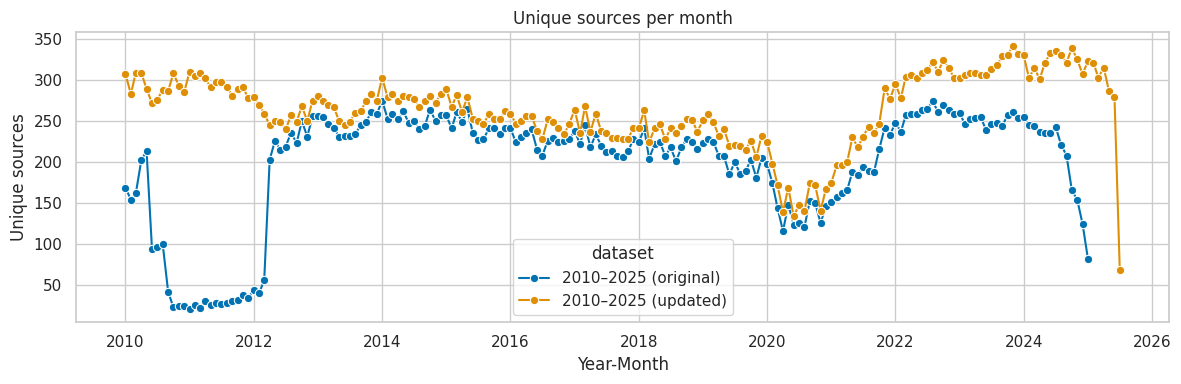

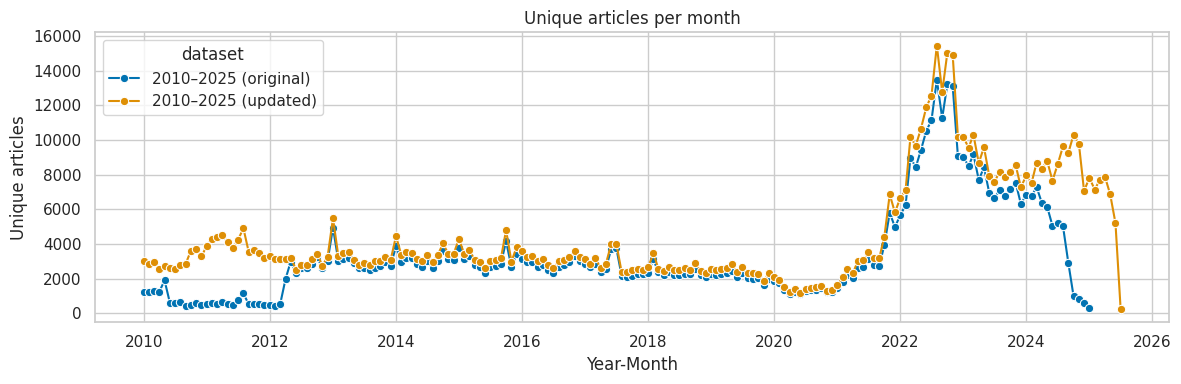

In [19]:
# Monthly plots: unique sources and unique articles per month across datasets

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare monthly aggregates for updated 2010–2025 (if available), original 2010–2025, and preceding period
plots = []

if 'orig_df' in globals() and not orig_df.empty:
    m_orig = (
        orig_df.dropna(subset=["year_month"])  # already parsed
        .groupby("year_month")
        .agg(unique_articles=("article_id", "nunique"), unique_sources=("source_title", "nunique"))
        .reset_index()
    )
    m_orig["dataset"] = "2010–2025 (original)"
    plots.append(m_orig)

if 'upd_df' in globals() and not upd_df.empty:
    m_upd = (
        upd_df.dropna(subset=["year_month"])  # already parsed
        .groupby("year_month")
        .agg(unique_articles=("article_id", "nunique"), unique_sources=("source_title", "nunique"))
        .reset_index()
    )
    m_upd["dataset"] = "2010–2025 (updated)"
    plots.append(m_upd)

if 'prev_df' in globals() and not prev_df.empty:
    m_prev = (
        prev_df.dropna(subset=["year_month"])  # already parsed
        .groupby("year_month")
        .agg(unique_articles=("article_id", "nunique"), unique_sources=("source_title", "nunique"))
        .reset_index()
    )
    m_prev["dataset"] = "2000–2009"
    plots.append(m_prev)

if not plots:
    print("No datasets available for monthly plots.")
else:
    monthly_all = pd.concat(plots, ignore_index=True)
    monthly_all = monthly_all.sort_values("year_month")

    # Plot unique sources per month
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.lineplot(data=monthly_all, x="year_month", y="unique_sources", hue="dataset", ax=ax, marker="o")
    ax.set_title("Unique sources per month")
    ax.set_xlabel("Year-Month")
    ax.set_ylabel("Unique sources")
    plt.tight_layout()
    plt.show()

    # Plot unique articles per month
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.lineplot(data=monthly_all, x="year_month", y="unique_articles", hue="dataset", ax=ax, marker="o")
    ax.set_title("Unique articles per month")
    ax.set_xlabel("Year-Month")
    ax.set_ylabel("Unique articles")
    plt.tight_layout()
    plt.show()
